In [1]:
import msprime
from demography import DemographicTopology
import numpy as np

In [2]:
## Defining Topology
dem = DemographicTopology(['a', 'admix', 'b', 'c'])

dem.add_admixture_event('admix', 'admixPa1', 'admixPa2') # Admixture event: from Admix to Admixpa1 and Admixpa2
dem.add_merge_event('a', 'admixPa1', 'aAdmix')  # Merge event: from A and Admixpa1 to Aadmix
dem.add_merge_event('b', 'admixPa2', 'bAdmix')
dem.add_merge_event('aAdmix', 'bAdmix', 'subAnc')
dem.add_merge_event('subAnc', 'c', 'anc')


[Event 0] Admixture: admix -> admixPa1 & admixPa2
[Event 2] Merge: a & admixPa1 -> aAdmix
[Event 3] Merge: b & admixPa2 -> bAdmix
[Event 4] Merge: aAdmix & bAdmix -> subAnc
[Event 5] Merge: subAnc & c -> anc


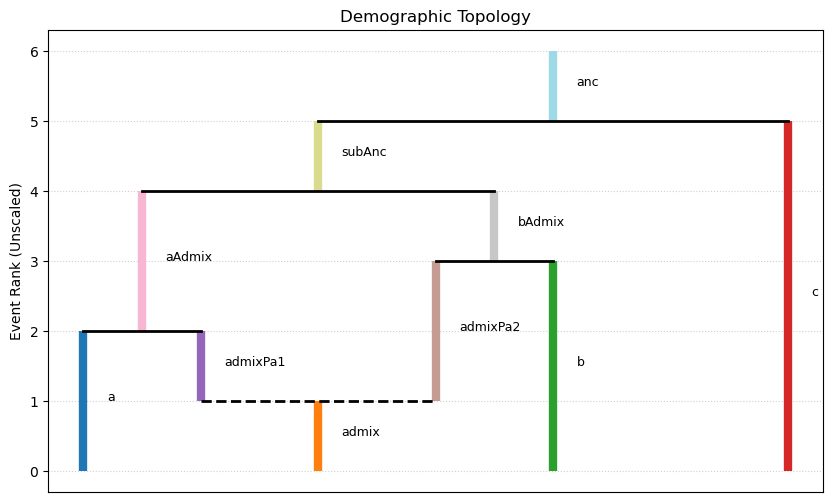

In [3]:
# Under scale = False, you can plot the graph without knowing the parameters. 
dem.plot_demography(scale = False)

In [6]:
# Effective Population Sizes
dem.set_node_ne('a', 5000)
dem.set_node_ne('b', 5000)
dem.set_node_ne('c', 5000)
dem.set_node_ne('admix', 5000)
dem.set_node_ne('admixPa1', 5000)
dem.set_node_ne('admixPa2', 5000)
dem.set_node_ne('aAdmix', 5000)
dem.set_node_ne('bAdmix', 5000)
dem.set_node_ne('subAnc', 5000)
dem.set_node_ne('anc', 5000)

dem.set_admixture_parameters('admix',50, 0.75, 'admixPa1')
dem.set_merge_time('aAdmix', 150)
dem.set_merge_time('bAdmix', 400)
dem.set_merge_time('subAnc',1000)
dem.set_merge_time('anc', 1500)
dem.finalize_root()

[Finalize] Set anc time_end to infinity.


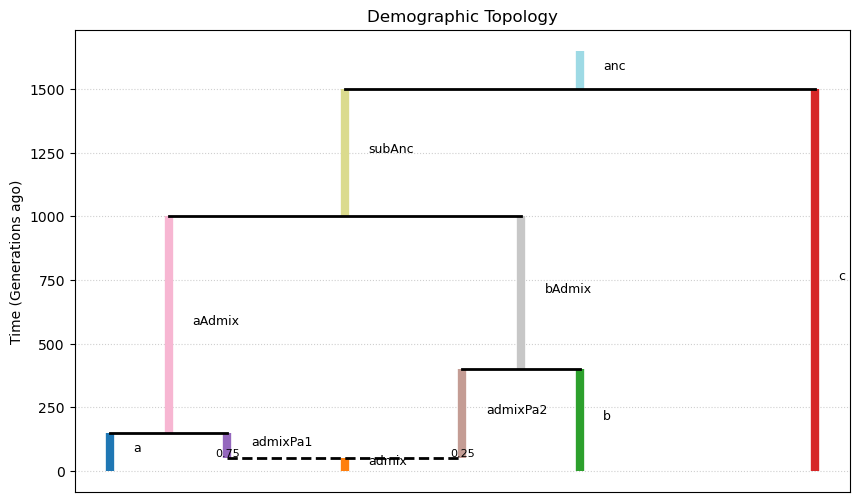

In [7]:
# This plot is sclaed by true time
dem.plot_demography(scale = True)

In [8]:
# For simulation block, first translate to msprime format
from simulation_methods import to_msprime_demography

msp = to_msprime_demography(dem)
msp.debug()

In [9]:
# This block output the pruned snp frequencies table
from simulation_methods import simulate_msprime, simulate_snp_pruning

# recombination rate set to default 1e-8, thus sequence_length * recombination_rate gives the number of morgans.
mts = simulate_msprime(dem, 
                       sequence_length = 3e7, 
                       recombination_rate = 1e-7, 
                       mutation_rate = 1e-7,
                       samples_per_pop = {'a': 20, 'b': 20, 'c': 20, 'admix': 20})

ids, freq_array = simulate_snp_pruning(
    mts,
    dem,
    temporal_folder = './plink_output',
    cutoff_time = 1500
)

Running: plink --vcf plink_output/snp_ts.vcf --make-bed --out plink_output/snp_ts --double-id --allow-extra-chr --silent
Running: plink --bfile plink_output/snp_ts --indep-pairwise 100 5 0.2 --out plink_output/pruned --allow-extra-chr --silent
LD pruning complete. Kept 22858 SNPs.


In [72]:
from inference_methods import calculate_treemix_covariance

w_hat, w_se = calculate_treemix_covariance(
    freq_array,
    min_maf = 0.05,
    block_size_snps = 400
)

In [63]:
snp_data = {}
matrices, events, admixture_map, admixture_map_id = dem.get_topology_matrix_representation()
snp_data['n_leaves'] = len(dem.initial_leaves)
snp_data['n_nodes'] = len(dem.nodes) 
snp_data['n_events'] = len(dem.ordered_events)
snp_data['n_admixture'] = dem.n_admix
snp_data['migration_matrices'] = matrices

m = []
for i in admixture_map_id.keys():
    m.append([i, admixture_map_id[i]['child']] + [i for i in admixture_map_id[i]['parents']])
snp_data['admixture_map'] = m
snp_data['admixture_indices'] = [i+2 for i in admixture_map_id.keys()]
snp_data['fixed_indices_shifted'] = [i for i in range(2,snp_data['n_events']+2) if i not in snp_data['admixture_indices']]
snp_data['fixed_indices'] = [i-1 for i in snp_data['fixed_indices_shifted']]

In [66]:
snp_data['effective_N'] = [5000] * 10
snp_data['w_hat'] = w_hat
snp_data['w_se'] = w_se

In [73]:
from cmdstanpy import CmdStanModel
model = CmdStanModel(stan_file = 'snp_inference.stan')

11:38:48 - cmdstanpy - INFO - compiling stan file /Users/qichen/github/admix_stan/new_pipeline/snp_inference.stan to exe file /Users/qichen/github/admix_stan/new_pipeline/snp_inference
11:39:00 - cmdstanpy - INFO - compiled model executable: /Users/qichen/github/admix_stan/new_pipeline/snp_inference


In [74]:
fit = model.sample(data = snp_data, chains = 4, iter_warmup=1000, iter_sampling = 3000)

11:39:01 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]





chain 1:   2%|▎         | 100/4000 [00:00<00:33, 117.48it/s, (Warmup)]



chain 1:  12%|█▎        | 500/4000 [00:01<00:05, 613.18it/s, (Warmup)]




chain 1:  18%|█▊        | 700/4000 [00:01<00:04, 807.57it/s, (Warmup)]

chain 1:  22%|██▎       | 900/4000 [00:01<00:03, 993.09it/s, (Warmup)]



chain 1:  25%|██▌       | 1000/4000 [00:01<00:03, 993.09it/s, (Sampling)]

chain 1:  28%|██▊       | 1100/4000 [00:01<00:02, 1118.78it/s, (Sampling)]


chain 1:  32%|███▎      | 1300/4000 [00:01<00:02, 1213.99it/s, (Sampling)]


chain 1:  38%|███▊      | 1500/4000 [00:01<00:01, 1278.01it/s, (Sampling)]


chain 1:  42%|████▎     | 1700/4000 [00:01<00:01, 1351.56it/s, (Sampling)]


chain 1:  48%|████▊     | 1900/4000 [00:02<00:01, 1375.00it/s, (Sampling)]


chain 1:  52%|█████▎    | 2100/4000 [00:02<00:01, 1412.10it/s, (Sampling)]


chain 1:  57%|█████▊    | 2300/4000 [00:02<00:01


11:39:04 - cmdstanpy - INFO - CmdStan done processing.
11:39:04 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Location parameter is nan, but must be finite! (in 'snp_inference.stan', line 83, column 12 to column 54)
Exception: normal_lpdf: Location parameter is nan, but must be finite! (in 'snp_inference.stan', line 83, column 12 to column 54)
Exception: normal_lpdf: Location parameter is nan, but must be finite! (in 'snp_inference.stan', line 83, column 12 to column 54)
Consider re-running with show_console=True if the above output is unclear!


11:39:04 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 7 divergent transitions (0.2%)
	Chain 2 had 38 divergent transitions (1.3%)
	Chain 3 had 36 divergent transitions (1.2%)
	Chain 4 had 5 divergent transitions (0.2%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


In [75]:
fit.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-1948.520000,0.037850,1.937780,1.743980,-1952.230000,-1948.140000,-1946.070000,2972.27,3045.940,375.619,1.00104
times[1],797.315000,0.254094,17.557700,17.316100,768.581000,797.102000,826.243000,4827.03,4319.110,610.013,1.00081
times[2],3.731140,0.040340,3.669130,2.646070,0.209126,2.603590,11.069100,6251.66,4603.940,790.049,1.00010
times[3],18.257000,0.408078,15.778800,13.557900,1.103350,14.063700,50.090200,2325.55,1230.790,293.889,1.00146
times[4],524.712000,0.524171,21.998100,20.555900,485.502000,526.214000,558.482000,2240.55,1083.690,283.148,1.00191
...,...,...,...,...,...,...,...,...,...,...,...
"W[10,6]",-0.017567,0.000007,0.000266,0.000248,-0.017948,-0.017597,-0.017074,2230.16,973.106,281.835,1.00148
"W[10,7]",-0.017932,0.000003,0.000200,0.000191,-0.018273,-0.017925,-0.017615,6532.90,6171.290,825.590,1.00033
"W[10,8]",-0.017567,0.000007,0.000266,0.000248,-0.017948,-0.017597,-0.017074,2230.16,973.106,281.835,1.00148
"W[10,9]",-0.007073,0.000004,0.000227,0.000218,-0.007457,-0.007068,-0.006705,3027.76,1515.480,382.631,1.00160
